In [5]:
from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn import metrics
import tqdm


from akida_models import fetch_file, akidanet_imagenet
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

import numpy as np
import sys, os

import dataset_BCICIV2a
from config_BCICIV2a import Config

from PyEMD import EMD, EEMD

import cv2



config = Config()


# Choose from: 'Left', 'Right', 'Foot' and 'Tongue'
config.used_classes = ['Right', 'Tongue']


config.t_start = -0.1
config.t_end = 3.0

config.n_csp_components = 3

In [6]:
# Create a base model without top layers
base_model = akidanet_imagenet(input_shape=(224, 224, 3),
                               classes=2,
                               alpha=0.5,
                               include_top=False,
                               pooling='avg')

# Get pretrained quantized weights and load them into the base model
pretrained_weights = fetch_file(
    origin="https://data.brainchip.com/models/AkidaV2/akidanet/akidanet_imagenet_224_alpha_0.5.h5",
    fname="akidanet_imagenet_224_alpha_0.5.h5",
    cache_subdir='models')

base_model.load_weights(pretrained_weights, by_name=True)
base_model.summary()

Model: "akidanet_0.50_224_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 224, 224, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv_0 (Conv2D)             (None, 112, 112, 16)      432       
                                                                 
 conv_0/BN (BatchNormalizat  (None, 112, 112, 16)      64        
 ion)                                                            
                                                                 
 conv_0/relu (ReLU)          (None, 112, 112, 16)      0         
                                                                 
 conv_1 (Conv2D)             (None, 112, 112, 32)      4608      
                                               

In [7]:
from keras import Model
from keras.layers import Activation, Dropout, Reshape
from akida_models.layer_blocks import dense_block

x = base_model.output
x = dense_block(x,
                units=512,
                name='fc1',
                add_batchnorm=True,
                relu_activation='ReLU7.5')
x = Dropout(0.5, name='dropout_1')(x)
x = dense_block(x,
                units=2,
                name='predictions',
                add_batchnorm=False,
                relu_activation=False)
x = Activation('softmax', name='act_softmax')(x)
x = Reshape((2,), name='reshape')(x)

# Build the model
model_keras = Model(base_model.input, x, name='akidanet')

model_keras.summary()

Model: "akidanet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 224, 224, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv_0 (Conv2D)             (None, 112, 112, 16)      432       
                                                                 
 conv_0/BN (BatchNormalizat  (None, 112, 112, 16)      64        
 ion)                                                            
                                                                 
 conv_0/relu (ReLU)          (None, 112, 112, 16)      0         
                                                                 
 conv_1 (Conv2D)             (None, 112, 112, 32)      4608      
                                                          

In [8]:
subject_accs = []
for subject_id in tqdm.tqdm(range(1, 2)):

    if subject_id == 4:
        continue

    #old_stdout = sys.stdout
    #sys.stdout = open(os.devnull, 'w')

    X, y = dataset_BCICIV2a.subject_dataset(config, subject_id)

    shuffle_indices = np.random.permutation(len(y))

    
    X = X[shuffle_indices]
    y = y[shuffle_indices]

    crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


    acc = []
    Y_preds = []

    for train_index, valid_index in crossValidation_KF.split(X,y):
        X_train = X[train_index][:]
        Y_train = y[train_index][:]
        X_valid = X[valid_index][:]
        Y_valid = y[valid_index][:]
        

        csp = CSP(n_components=3, reg=None, log=None, norm_trace=False, transform_into='csp_space')

        X_train_csp = csp.fit_transform(X_train, Y_train)
        X_valid_csp = csp.transform(X_valid)

        eemd = EMD()
        X_train_imf_ch1 = np.array([eemd(X_train[i,6], max_imf=1) for i in range(X_train.shape[0])])[:, 0]
        X_valid_imf_ch1 = np.array([eemd(X_valid[i,6], max_imf=1) for i in range(X_valid.shape[0])])[:, 0]

        X_train_imf_ch2 = np.array([eemd(X_train[i,8], max_imf=1) for i in range(X_train.shape[0])])[:, 0]
        X_valid_imf_ch2 = np.array([eemd(X_valid[i,8], max_imf=1) for i in range(X_valid.shape[0])])[:, 0]

        X_train_imf_ch3 = np.array([eemd(X_train[i,10], max_imf=1) for i in range(X_train.shape[0])])[:, 0]
        X_valid_imf_ch3 = np.array([eemd(X_valid[i,10], max_imf=1) for i in range(X_valid.shape[0])])[:, 0]


        #CSP = (115, 3, 651)
        #IMFs = (115, 651)

        X_train_combined = []
        X_valid_combined  = []
        for i in range(len(X_train_csp)):

            X_train_combined.append(
                np.array(
                [
                    cv2.resize(np.outer(X_train_csp[i, 0, :], X_train_imf_ch1[i].T), (224,224), interpolation=cv2.INTER_CUBIC),

                    cv2.resize(np.outer(X_train_csp[i, 1, :], X_train_imf_ch2[i].T), (224,224), interpolation=cv2.INTER_CUBIC),
                    
                    cv2.resize(np.outer(X_train_csp[i, 2, :], X_train_imf_ch3[i].T), (224,224), interpolation=cv2.INTER_CUBIC)
                ])
            
            )

        for i in range(len(X_valid_csp)):
            X_valid_combined.append(
                np.array(
                [
                    cv2.resize(np.outer(X_valid_csp[i, 0, :], X_valid_imf_ch1[i].T), (224,224), interpolation=cv2.INTER_CUBIC),

                    cv2.resize(np.outer(X_valid_csp[i, 1, :], X_valid_imf_ch2[i].T), (224,224), interpolation=cv2.INTER_CUBIC),
                    
                    cv2.resize(np.outer(X_valid_csp[i, 2, :], X_valid_imf_ch3[i].T), (224,224), interpolation=cv2.INTER_CUBIC)
                ])
            
            )
        

        X_train_combined = np.array(X_train_combined).transpose(0,3,2,1)
        X_valid_combined = np.array(X_valid_combined).transpose(0,3,2,1)

        Y_train = tf.keras.utils.to_categorical(Y_train, num_classes = 2)
        Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = 2)
    
    
        model_keras.compile(
                loss= CategoricalCrossentropy(from_logits=True, label_smoothing=0.01),
                optimizer=keras.optimizers.Adam(learning_rate=1e-3, weight_decay = 2e-5), 
                metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
        ) 


        history = model_keras.fit(X_train_combined, Y_train, validation_data=(X_valid_combined, Y_valid), epochs=10, batch_size=8, verbose=1)


    #sys.stdout.close()
    #sys.stdout = old_stdout



  0%|          | 0/1 [00:00<?, ?it/s]

Extracting EDF parameters from /home/antaeus/Neurobus/BCICIV_2a_gdf/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-0.1, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 72 events and 776 original time points ...
0 bad epochs dropped
Loading data for 72 events and 776 original time points ...


/usr/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


0 bad epochs dropped
Computing rank from data with rank=None
    Using tolerance 4.1e-05 (2.2e-16 eps * 17 dim * 1.1e+10  max singular value)
    Estimated rank (data): 17
    data: rank 17 computed from 17 data channels with 0 projectors
Reducing data rank from 17 -> 17
Estimating class=0.0 covariance using EMPIRICAL
Done.
Estimating class=1.0 covariance using EMPIRICAL
Done.
Epoch 1/10
15/15 [==============================] - 8s 269ms/step - loss: 0.8382 - acc: 0.4870 - val_loss: 0.9301 - val_acc: 0.4828
Epoch 2/10
15/15 [==============================] - 3s 228ms/step - loss: 0.8369 - acc: 0.4957 - val_loss: 0.9161 - val_acc: 0.4828
Epoch 3/10
15/15 [==============================] - 4s 243ms/step - loss: 0.8350 - acc: 0.4522 - val_loss: 0.8466 - val_acc: 0.4828
Epoch 4/10
15/15 [==============================] - 4s 236ms/step - loss: 0.8328 - acc: 0.5130 - val_loss: 0.9053 - val_acc: 0.5172
Epoch 5/10
15/15 [==============================] - 3s 227ms/step - loss: 0.8309 - acc: 0.50

  0%|          | 0/1 [00:34<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
np.array(X_train_combined).shape

(10, 3, 224, 224)

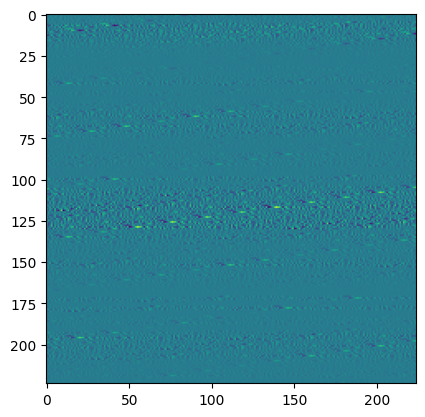

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(X_train_combined[0][0])